# Gender Bias in Occupation Prediction: A BiasBios Analysis

## Project Overview

This project uses the BiasBios dataset to train a logistic regression 
classifier that predicts occupation from professional biography text. Beyond 
standard evaluation, the project includes an ethics analysis: the top-weighted 
TF-IDF features per occupation class are extracted from the trained model, and 
their correlation with ground-truth gender labels is computed. This surfaces 
the gendered vocabulary driving predictions, demonstrating how gender bias can 
persist in a model even when gender is not an explicit input feature.

The inspection motivates a controlled debiasing intervention: a second model 
is trained with a targeted pronoun stop list, holding all other hyperparameters 
constant. The two models are compared on both classification performance and 
gender signal strength, demonstrating that interpretability can enable precise, 
measurable bias reduction.

## Imports & Setup

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import classification_report
from scipy.sparse import vstack
from scipy.stats import pointbiserialr
from scipy.sparse import spmatrix

from datasets import load_dataset
from pathlib import Path

import os
import random
from enum import StrEnum

# Allow to show all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Set seaborn theme easy to read for colorblind readers
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


In [234]:
# Globals
DATA_PATH = Path("biasbios.parquet")
NOTEBOOK_SEED = 42

In [235]:
# Ensure Reproducibility
np.random.seed(NOTEBOOK_SEED)
random.seed(NOTEBOOK_SEED)

`BiasInBiosColumns` are used to reduce typos in accessing columns in the pandas DateFrame:

In [236]:
# Description of Dataset columns

class BiasInBiosColumns(StrEnum):
    """Column names for the Bias in Bios dataset.

    Source: https://huggingface.co/datasets/LabHC/bias_in_biostrain
    License: MIT
    """

    # Core columns
    BIO = "hard_text"
    PROFESSION = "profession"
    GENDER = "gender"
    SPLIT = "split"

    # Columns added through data prep
    PROFESION_TEXT = "profesion_text"
    GENDER_TEXT = "gender_text"
    
    
class DataSplit(StrEnum):
    """Valid Values for column BiasInBiosColumns.SPLIT"""
    TRAIN = "train"
    DEV = "dev"
    TEST = "test"

VALID_SPLITS = {s.value for s in DataSplit}

In [237]:
GENDER_TO_TEXT = [
        "male",
        "female"
]

PROFESSION_TO_TEXT = [
    "accountant",
    "architect",
    "attorney",
    "chiropractor",
    "comedian",
    "composer",
    "dentist",
    "dietitian",
    "dj",
    "filmmaker",
    "interior_designer",
    "journalist",
    "model",
    "nurse",
    "painter",
    "paralegal",
    "pastor",
    "personal_trainer",
    "photographer",
    "physician",
    "poet",
    "professor",
    "psychologist",
    "rapper",
    "software_engineer",
    "surgeon",
    "teacher",
    "yoga_teacher",
]

## Load Data 

De-Areaga et al. (2019) compiled a dataset of professional biographies, along with their occupations and genders, from a web crawl. Although De-Artega et al. (2019) released the code to crawl the dataset, they didn’t release the dataset itself. Ravfogel et al. (2020) released a freely downloadable version of the crawled dataset for their own use.  The version used in this analysis is a Hugging Face Dataset upload by Laboratoire Hubert Curien, a French University. It uses the same data and training/dev/test splits as Ravfogel et al. (2020). It should be noted that the Ravfogel et al. (2020) version has 396,189 datapoints, which is slightly smaller than the De-Artega et al. (2019) version, as 5,557 biographies were no longer available on OpenCrawl. The analysis combines the four splits into a single parquet file and adds a split column to maintain consistency with the original data. 

Automatically download dataset if it does not exist. In any case `biasbios_df` will contain a pandas DataFrame with Bias Bios Dataset: 

In [238]:
def download_bias_in_bios(data_path: Path):
    """Download bias_in_bios dataset and save to CSV.
    
    Args:
        data_path: Path object where CSV will be written.
        
    Raises:
        AssertionError: If load_dataset().to_pandas() returns non-DataFrame.
    """
     
    dfs : list[pd.DataFrame] = []
    for split in VALID_SPLITS:
        df = load_dataset("LabHC/bias_in_bios", split=split).to_pandas()

        # can return an iterator but it shouldn't assert corrrectness 
        assert isinstance(df, pd.DataFrame), "Incorrect Dataset"
        df[BiasInBiosColumns.SPLIT] = split
        dfs.append(df)
    
    full_df = pd.concat(dfs, ignore_index=True, axis=0) 
    assert isinstance(full_df, pd.DataFrame), "Incorrect Dataset"
    # create CSV 
    data_path.parent.mkdir(parents=True, exist_ok=True)
    full_df.to_parquet(data_path) 

def load_and_cache_data(data_path: Path) -> pd.DataFrame:

    """Load bias_in_bios dataset, downloading and caching if necessary.

    Args:
        data_path: Path where cached CSV is/will be stored.

    Returns:
        DataFrame with bias_in_bios data and split column.
    """
    if not data_path.exists():
        download_bias_in_bios(data_path)

    return pd.read_parquet(data_path)

In [239]:
biasbios_df = load_and_cache_data(DATA_PATH)

A quick check on the data gives a first glimpse into the dataset: 

In [240]:
biasbios_df.head()

,hard_text,profession,gender,split
0,"He specializes in development economics, house...",21,0,test
1,He started out as a DJ and music producer in t...,5,0,test
2,"She is averse to all things scary or sad, so s...",4,1,test
3,"Prior to joining USC, she was a mobile news ed...",21,1,test
4,"Previously, she served as an assistant profess...",21,1,test


In [241]:
biasbios_df.shape

(396189, 4)

In [242]:
biasbios_df.dtypes

hard_text       str
profession    int64
gender        int64
split           str
dtype: object

The size of the dataset are 396,189 rows and 4 columns. The columns in the dataset are `hard_text` as string, containing the biographies; `profession` as integer, containing the occupation; `gender`, containing the gender of the professional as integer; and `split` as string, containing “dev”, “train”, or “dev” depending on the data split from the original. The dev (development) set is a held-out split used to tune model hyperparameters during training, keeping the test set unseen until final evaluation. The profession and gender are categorical variables encoded as integers, as can be seen here: 

In [243]:
biasbios_df[BiasInBiosColumns.PROFESSION].value_counts().sort_index()

profession
0       5633
1      10108
2      32570
3       2655
4       2809
5       5599
6      14585
7       3952
8       1486
9       6996
10      1461
11     19941
12      7491
13     18950
14      7734
15      1765
16      2523
17      1430
18     24269
19     40998
20      7014
21    118076
22     18380
23      1403
24      6912
25     13587
26     16203
27      1659
Name: count, dtype: int64

In [244]:
biasbios_df[BiasInBiosColumns.GENDER].value_counts().sort_index()

gender
0    213543
1    182646
Name: count, dtype: int64

Having integer values will hamper interpretations which is an ovious data quality issue that needs to be dealt with. 

## Data Preparation

### Check for missing values

In [245]:
biasbios_df.isnull().sum()

hard_text     0
profession    0
gender        0
split         0
dtype: int64

No missing values in this data, so no need to clean null values.

### Decoding Categorical Values

Although having integer values for “gender” and “professional” aids in training, it hampers interpretation. Therefore, during data cleaning, two columns were added: “profession_text” and “gender_text,” which contain textual representations of profession and gender, respectively:

In [246]:
def add_textual_representations(df: pd.DataFrame) -> pd.DataFrame:
    """ Adds textual representations for gender and profession 

    Args: 
        df: BiasBios Dataset 

    Return: 
        pd.DataFrame: copy of the original dataframe with textual represenations of gender as "gender_text" and "profession_text".
        
    """ 

    df = df.copy()
    df[BiasInBiosColumns.GENDER_TEXT] = df[BiasInBiosColumns.GENDER].map(lambda x: GENDER_TO_TEXT[x])
    df[BiasInBiosColumns.PROFESION_TEXT] = df[BiasInBiosColumns.PROFESSION].map(lambda x: PROFESSION_TO_TEXT[x])
    return df 

biasbios_df = add_textual_representations(biasbios_df)

Here is a sanity check that the addition worked: 

In [247]:
biasbios_df.head()

,hard_text,profession,gender,split,gender_text,profesion_text
0,"He specializes in development economics, house...",21,0,test,male,professor
1,He started out as a DJ and music producer in t...,5,0,test,male,composer
2,"She is averse to all things scary or sad, so s...",4,1,test,female,comedian
3,"Prior to joining USC, she was a mobile news ed...",21,1,test,female,professor
4,"Previously, she served as an assistant profess...",21,1,test,female,professor


## Feature Engineering

Before going into the feature engineering, the dataset is split into a training, dev and test set. To keep it in sync with the plethora of resarch, it is split in the same manner as Ravfogel et. al (2020) did:

In [248]:
train_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.TRAIN]
dev_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.DEV]
test_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.TEST]

The size of each dataset are: 

In [269]:
len(train_df), len(dev_df), len(test_df)

(257478, 39642, 99069)

There are 257,478 bios in train, 39,642 in dev and 99,069 in test. 

First it's necessary to turn the biographies into a numerical vector. In this analysis a standard classical NLP method is used: TF-IDF. This splits the text into words, counts the word frequency (TF), and downweights terms that appear across most documents (IDF: inverse document frequency). Terms appearing in more than 99% of documents are excluded entirely. Stopword removal is deliberately skipped to preserve explicit gender indicators such as 'he' and 'she', which are central to the ethics analysis. Log normalisation is applied to raw term frequency to reduce the dominance of repetitive terms. It is fitted on the train dataset only to prevent data leakage: 

In [249]:
tf_idf = TfidfVectorizer(
    analyzer="word",
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 1),
    max_features=50_000,
    min_df=0.001,
    max_df=0.99,
    sublinear_tf=True,
)
tf_idf = tf_idf.fit(train_df[BiasInBiosColumns.BIO])


Next the biography text is vectorized for each split, producing a sparse matrix of biography vectors. The sparse format is preserved throughout to avoid the memory cost of dense conversion, which at 50k features and 99k test documents would require approximately 20GB:

In [250]:
X_train = tf_idf.transform(train_df[BiasInBiosColumns.BIO])
X_dev = tf_idf.transform(dev_df[BiasInBiosColumns.BIO])
X_test = tf_idf.transform(test_df[BiasInBiosColumns.BIO])

The target labels are the integer profession codes, which sklearn accepts directly without further encoding:

In [251]:
y_train = train_df[BiasInBiosColumns.PROFESSION]
y_dev = dev_df[BiasInBiosColumns.PROFESSION]
y_test = test_df[BiasInBiosColumns.PROFESSION]

## Training A Profession Classifier Based On Bio Text

### Defining A Baseline
Before training the actual classifier, it is prudent to understand the correct baseline. One of the simplest and most effective baselines is to predict the most common class of professions:

In [252]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)
y_baseline = baseline.predict(X_test)

print(
    classification_report(
        y_test, y_baseline, target_names=PROFESSION_TO_TEXT, zero_division=0)
)

                   precision    recall  f1-score   support

       accountant       0.00      0.00      0.00      1409
        architect       0.00      0.00      0.00      2528
         attorney       0.00      0.00      0.00      8143
     chiropractor       0.00      0.00      0.00       664
         comedian       0.00      0.00      0.00       703
         composer       0.00      0.00      0.00      1401
          dentist       0.00      0.00      0.00      3647
        dietitian       0.00      0.00      0.00       989
               dj       0.00      0.00      0.00       372
        filmmaker       0.00      0.00      0.00      1750
interior_designer       0.00      0.00      0.00       366
       journalist       0.00      0.00      0.00      4986
            model       0.00      0.00      0.00      1874
            nurse       0.00      0.00      0.00      4738
          painter       0.00      0.00      0.00      1935
        paralegal       0.00      0.00      0.00       

The baseline is justified by these numbers over a simpler approach such as using a discrete uniform distribution. There are 28 professions, so random guessing would yield an accuracy of 1/28 ~= 3.57%. In the case of predicting the most frequent class, the baseline yields 30% accuracy. The exact macro averages and weighted averages will be discussed against the actual model later.

What is interesting, however, is the predominance of professors in the dataset. 30% of all bios were professor bios. This over-representation of professors is due to the methodology of using a web crawl, as academic bios are far more common online.

## Training the Profession Classifier Model
For this project a logistic regression classifier was chosen. The motivation is to show that it is fast and simple to train and easier to interpret compared to more complex models such as neural networks. It is this interpretability that will be used later in this notebook to investigate whether the model learned a bias. However, interpretability comes at a price. Its expressiveness is severely limited both by its linearity and parameter count. So the very thing that makes it fast and interpretable also makes it worse on most problems compared to modern deep learning.

Before training the profession classifier, hyperparameters need to be set. In logistic regression, most hyperparameters have sensible defaults that work well without tuning. The exception is the C parameter, which is an inverse regularisation term: smaller values mean stronger regularisation, while very large values approach no regularisation at all. Because C directly controls the bias-variance tradeoff and is sensitive to the scale of the feature space, it warrants a dedicated search.

It is good practice to use a hyperparameter search to find the best value. Grid search is a good candidate when training cost is not prohibitively long and the order of magnitude matters more than the precise value. Both conditions hold here. However, to avoid tuning the hyperparameters to the test set, a separate dev set is used. Ravfogel et al. (2020) have already defined one as part of their original split:

In [253]:
split = PredefinedSplit([-1] * X_train.shape[0] + [0] * X_dev.shape[0])
X_traindev = vstack([X_train, X_dev])
y_traindev = pd.concat([y_train, y_dev]).reset_index(drop=True)

gs = GridSearchCV(
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
    ),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0]},
    cv=split,
    scoring="f1_macro",
)
gs.fit(X_traindev, y_traindev)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...pe=(297120,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [254]:
gs.best_params_

{'C': 1.0}

The grid search identified C=1.0 as the best value. Using this, the logistic regression is trained with the lbfgs solver for a maximum of 1000 iterations, stopping early if convergence is reached. It is important to note that balanced class weighting is used. This downweights the loss contribution of majority classes and upweights minority classes, which reduces overall accuracy but produces more meaningful predictions across all 28 professions. Given the strong overrepresentation of professors in this dataset, balanced weighting prevents the model from defaulting to majority-class predictions at the expense of rarer occupations:

In [255]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

The logistic regression fitted model succesfully. Next it can be evaluated against the baseline. 

## Evaluation

### Proffesion Classifier Model

In [256]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=PROFESSION_TO_TEXT))


                   precision    recall  f1-score   support

       accountant       0.56      0.78      0.66      1409
        architect       0.59      0.65      0.62      2528
         attorney       0.89      0.83      0.86      8143
     chiropractor       0.47      0.84      0.60       664
         comedian       0.51      0.78      0.62       703
         composer       0.70      0.85      0.77      1401
          dentist       0.93      0.92      0.93      3647
        dietitian       0.66      0.86      0.75       989
               dj       0.44      0.72      0.55       372
        filmmaker       0.70      0.82      0.75      1750
interior_designer       0.37      0.73      0.49       366
       journalist       0.69      0.73      0.71      4986
            model       0.67      0.79      0.72      1874
            nurse       0.81      0.83      0.82      4738
          painter       0.69      0.85      0.76      1935
        paralegal       0.45      0.75      0.56       

The primary evaluation metric is macro-averaged F1, which weights each class 
equally regardless of size — appropriate here given the substantial class 
imbalance in BiasBios (professor: 29,520 vs. rapper: 351). Accuracy would 
inflate results by over-representing majority classes.

The baseline achieves a macro F1 of 0.68 at 76% accuracy. The gap between 
the two reflects class imbalance rather than model failure — `class_weight='balanced'` 
gives underrepresented professions meaningful representation, as seen in the 
recall scores remaining relatively consistent across classes. The best 
performing classes are dentist, attorney, photographer, and nurse with F1 
scores of 0.93, 0.86, 0.85, and 0.82 respectively. Pastor scores lowest at 
0.44, which is surprising given that biographical text for clergy should 
contain relatively distinctive vocabulary.

Whether this performance is meaningful is best assessed in comparison with 
the dummy baseline.

## vs Baseline

In [257]:
print(
    classification_report(
        y_test, y_baseline, target_names=PROFESSION_TO_TEXT, zero_division=0
    )
)


                   precision    recall  f1-score   support

       accountant       0.00      0.00      0.00      1409
        architect       0.00      0.00      0.00      2528
         attorney       0.00      0.00      0.00      8143
     chiropractor       0.00      0.00      0.00       664
         comedian       0.00      0.00      0.00       703
         composer       0.00      0.00      0.00      1401
          dentist       0.00      0.00      0.00      3647
        dietitian       0.00      0.00      0.00       989
               dj       0.00      0.00      0.00       372
        filmmaker       0.00      0.00      0.00      1750
interior_designer       0.00      0.00      0.00       366
       journalist       0.00      0.00      0.00      4986
            model       0.00      0.00      0.00      1874
            nurse       0.00      0.00      0.00      4738
          painter       0.00      0.00      0.00      1935
        paralegal       0.00      0.00      0.00       

Compared to this majority class baseline, the logistic regression model improves macro averaged F1 from 0.02 to 0.68. This demonstrates that the model has learned meaningful discriminative features across professions rather than simply exploiting class imbalance.

## Ethics Analysis: The Direct Interpretability of Logistic Regression

In mechanistic interpretability, linear probes are trained on top of a model's internal representations to test what information is encoded at a given layer. The probe is a separate, lightweight classifier, a diagnostic tool layered on top of an opaque model to recover what the model itself cannot explain.

Logistic regression does not require this indirection. The weight matrix directly maps TF-IDF features to class predictions, meaning the model's decision logic is fully exposed without any additional machinery. The weights are the probe. This is not a deliberate design choice for interpretability; it is a consequence of the model's limited capacity. The same linearity that constrains its expressiveness is what makes its internal logic directly readable.

This allows a straightforward ethics analysis: the top-weighted features per occupation class are extracted from the weight matrix and their correlation with ground-truth gender labels is computed using the point-biserial correlation coefficient. If the model has learned to rely on gendered vocabulary to predict occupation, this will surface directly in the weights, with no separate probe required.


In [258]:
model.coef_.shape

(28, 4402)

The shape of 28 rows and 4402 columns means that the model has learned 4402 weights for each of the 28 professions. As logistic regression is expressed as:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k \cdot \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j \cdot \mathbf{x} + b_j}}$$

This is the softmax function, the same output layer used in modern neural classifiers. The probability of a class is higher if two conditions hold:

- the weight is large, and
- the input word or feature is strong.

As the input is not learned but provided by the environment, any ethical bias existing in the model is a direct consequence of the weight parameters. However, the weight alone does not determine a feature's influence. The actual contribution to the predicted class is the logit contribution: the product of the weight and the input signal strength. A feature with a large weight but weak presence in the input contributes less than a moderately weighted feature that appears strongly across many documents. It is therefore the logit contribution, not the weight alone, that determines how much a feature drives a prediction.

Using this analysis, we can identify the top 25 weights for each profession and determine whether their logit contributions correlate with the dataset's gender variable. The top 25 weights reflect the model's learned most important features, while the logit contributions reflect their actual influence on the prediction. If any of the logit contributions correlate strongly with gender, then gendered terms are predictors of the profession. 25 features account for less than 1% of the total weight vector, making this a conservative assessment of the model's decision logic.

In [259]:
def calculate_correlations_to_gender(
    model: LogisticRegression,
    tf_idf: TfidfVectorizer,
    X_test: spmatrix,
    test_df: pd.DataFrame,
    top_n: int,
    top_k: int,
) -> pd.DataFrame:
    """Compute gender correlations for the top logit contributions per profession.

    Args:
        model: Fitted LogisticRegression model.
        tf_idf: Fitted TfidfVectorizer.
        X_test: Sparse TF-IDF matrix for the test set.
        test_df: Test DataFrame containing the gender column.
        top_n: Number of top-weighted features to inspect per profession.
        top_k: Number of features to retain, ranked by gender correlation strength.

    Returns:
        DataFrame with top_k correlation values and feature names per profession.
    """
    indices = np.argsort(model.coef_, axis=1)[:, -top_n:]
    X_test_dense = X_test.toarray()

    correlations = np.zeros((28, top_n))

    for class_idx in range(28):
        for feat_idx in range(top_n):
            col_idx = indices[class_idx, feat_idx]
            logit_contribution = (
                X_test_dense[:, col_idx] * model.coef_[class_idx, col_idx]
            )

            corr, _ = pointbiserialr(test_df["gender"], logit_contribution)
            correlations[class_idx, feat_idx] = corr

    corr_sorted_idx = np.argsort(np.abs(correlations), axis=1)[:, ::-1][:, :top_k]
    idx = indices[np.arange(28)[:, None], corr_sorted_idx]

    feature_names = tf_idf.get_feature_names_out()
    top_k_correlations = correlations[np.arange(28)[:, None], corr_sorted_idx]
    top_k_features = feature_names[idx]

    corr_features = np.hstack((top_k_correlations, top_k_features))
    column_names = [f"corr_{k}_correlation" for k in range(top_k)] + [
        f"corr_{k}_feature" for k in range(top_k)
    ]

    result_df = pd.DataFrame(corr_features, columns=column_names)
    result_df["profession"] = PROFESSION_TO_TEXT
    return result_df



result_df = calculate_correlations_to_gender(
    model, tf_idf, X_test, test_df, 25, 25
)


Next the most strongly correlated feature of the top 25 model features is plotted: 

In [260]:
def plot_gender_correlations(
    df: pd.DataFrame,
    feature_rank: int = 0,
    save_to: str | None = None,
    ax=None,
) -> None:
    """Plot per-profession gender correlation of a ranked correlated feature.

    Args:
        df: Output DataFrame from calculate_correlations_to_gender.
        feature_rank: Rank of the feature to plot (0 = strongest correlation).
        save_to: Optional file path to save the figure.
        ax: Optional matplotlib Axes object. If None, a new figure is created.
    """
    corr_col = f"corr_{feature_rank}_correlation"
    feat_col = f"corr_{feature_rank}_feature"

    df = df.sort_values(corr_col, ascending=False).reset_index()
    df["gender_signal"] = df[corr_col].map(lambda x: "female" if x >= 0 else "male")

    if ax is None:
        plt.figure(figsize=(6, 6))
        ax = plt.gca()

    sns.barplot(df, x=corr_col, y="profession", orient="h", hue="gender_signal", ax=ax)

    for i, (_, row) in enumerate(df.iterrows()):
        is_female = df[corr_col][i] >= 0
        ax.text(
            0,
            i,
            row[feat_col],
            va="center",
            ha="right" if is_female else "left",
        )

    ax.legend(title="Gender signal")
    ax.set_xlabel("Point-biserial correlation with gender")
    ax.set_xlim(-1.0, 1.2)

    if save_to:
        plt.savefig(save_to, bbox_inches="tight", dpi=150)


The bar plot shows each profession sorted by the strength of its gender correlation. The width of the bar shows the correlation strength, and its color indicates whether it is related to female or male gender. Next to each bar the feature with the strongest logit-gender correlation is displayed.

The pattern is strikingly symmetric. "she" dominates the female-correlated professions at the top, including dietitian, nurse, yoga_teacher, model and teacher, while "he" dominates the male-correlated professions at the bottom, including chiropractor, surgeon, software_engineer, comedian and pastor, all at an absolute correlation of approximately 0.75. In the middle tier, profession-specific terms such as "nursing", "dr" and "software" dominate instead, suggesting the model relies on occupational vocabulary rather than gendered pronouns for these classes.

It is clear that the model has encoded a gender bias in its top parameters.

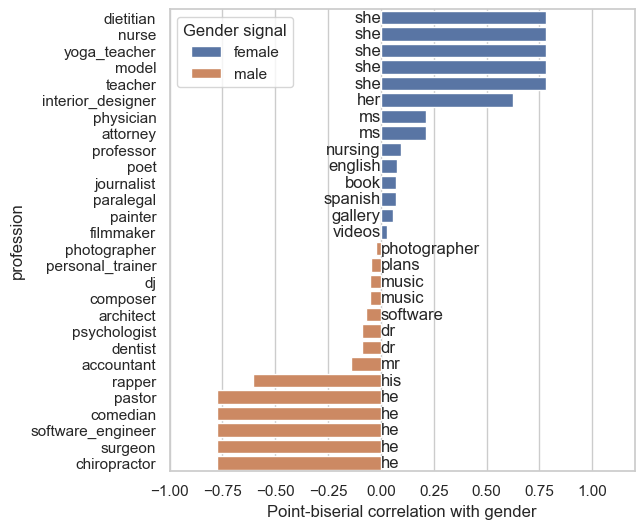

In [274]:
plot_gender_correlations(
    result_df, feature_rank=0, save_to="report/figures/gender_bias_correlation_0.png"
)


The second strongest correlated feature per profession shows a markedly different pattern: correlations drop sharply and occupation-specific terms such as "ms", "dr", "nutrition" and "computer" dominate, confirming that the gender signal is concentrated in pronouns rather than distributed across the weight vector.


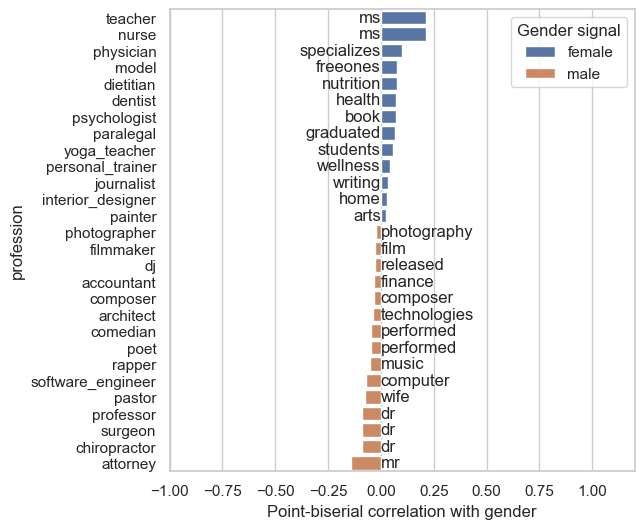

In [275]:
plot_gender_correlations(
    result_df, feature_rank=1, save_to="report/figures/gender_bias_correlation_1.png"
)


## Targeted Feature Intervention: Pronoun Removal

### Motivation
Weight inspection revealed a symmetric gender-signal pattern: female-dominated occupations rely on tokens such as *she*, *her*, and *ms* as top predictive features, while male-dominated occupations rely on *he*, *his*, and *mr*. This suggests the model is partly solving the occupation classification task via gendered language rather than occupational content. If interpretability exposes the mechanism, it also enables a targeted response: removing precisely those tokens and measuring the effect.




### Experimental Design
The intervention makes a single change to the baseline pipeline: a targeted 
pronoun stop list is added to the TF-IDF vectorizer. All other hyperparameters 
— including C, `class_weight`, `ngram_range`, and `max_features` — remain 
identical. This ensures any difference in results is attributable to pronoun 
removal alone.

The stop list consists of nine tokens: *she*, *her*, *hers*, *he*, *his*, 
*him*, *ms*, *mr*, and *mrs*. Non-binary pronouns such as *they*, *them*, and 
*their* were deliberately excluded, as these are also common in generic English 
usage and their removal would conflate gendered signal with high-frequency 
function word removal.

The two models are then compared on macro F1 and mean absolute point-biserial 
correlation of the top-25 features by weight, averaged across all occupation 
classes.


In [271]:
pronouns = ["she", "her", "hers", "he", "his", "him", "ms", "mr", "mrs"]
tf_idf_no_pronouns = TfidfVectorizer(
    analyzer="word",
    lowercase=True,
    stop_words=pronouns,
    ngram_range=(1, 1),
    max_features=50_000,
    min_df=0.001,
    max_df=0.99,
    sublinear_tf=True,
)
tf_idf_no_pronouns = tf_idf_no_pronouns.fit(train_df[BiasInBiosColumns.BIO])


In [272]:
X_train_no_pronouns = tf_idf_no_pronouns.transform(train_df[BiasInBiosColumns.BIO])
X_dev_no_pronouns = tf_idf_no_pronouns.transform(dev_df[BiasInBiosColumns.BIO])
X_test_no_pronouns = tf_idf_no_pronouns.transform(test_df[BiasInBiosColumns.BIO])


In [273]:
model_debias = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
)
model_debias.fit(X_train_no_pronouns, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter



### Results


First the macro F1 performance is compared to the biased model: 

In [265]:
y_pred_no_pronoun = model_debias.predict(X_test_no_pronouns)
print(classification_report(y_test, y_pred_no_pronoun, target_names=PROFESSION_TO_TEXT))

                   precision    recall  f1-score   support

       accountant       0.55      0.78      0.65      1409
        architect       0.59      0.65      0.62      2528
         attorney       0.89      0.83      0.86      8143
     chiropractor       0.43      0.84      0.57       664
         comedian       0.51      0.78      0.62       703
         composer       0.70      0.84      0.76      1401
          dentist       0.93      0.92      0.93      3647
        dietitian       0.66      0.85      0.74       989
               dj       0.43      0.73      0.54       372
        filmmaker       0.70      0.81      0.75      1750
interior_designer       0.37      0.73      0.49       366
       journalist       0.68      0.73      0.70      4986
            model       0.66      0.77      0.71      1874
            nurse       0.82      0.81      0.81      4738
          painter       0.69      0.85      0.76      1935
        paralegal       0.45      0.75      0.56       

The intervened model achieves a macro F1 of 0.68, identical to the baseline. 
Removing nine pronoun tokens has no measurable effect on classification 
performance, confirming that occupational predictive signal is carried by 
content vocabulary rather than gendered pronouns.

In [266]:
result_no_pronouns_df = calculate_correlations_to_gender(
    model_debias, tf_idf_no_pronouns, X_test_no_pronouns, test_df, 25, 25
)


Next a metric for comparing the bias is introduced. The mean absolute point-biserial 
correlation is defined as:

$$\bar{r} = \frac{1}{C}\sum_{c=1}^{C}\frac{1}{K}\sum_{k=1}^{K}|r_{c,k}|$$

where $C = 28$ occupation classes, $K = 25$ top-weighted features per class, 
and $r_{c,k}$ is the point-biserial correlation between feature $k$ in class 
$c$ and the binary gender label. A higher $\bar{r}$ indicates greater reliance 
on gender-correlated vocabulary in the model's decision logic.

In [267]:
def calculate_r(result_df: pd.DataFrame) -> float: 
    
    corr_cols = [col for col in result_df.columns if (col.startswith("corr") and col.endswith("correlation"))]

    r_pronouns = result_df[corr_cols].abs().values.mean(axis=1).mean()
    return float(r_pronouns)
calculate_r(result_df), calculate_r(result_no_pronouns_df)

(0.0346417902614786, 0.020790426279350984)

While performans stays the same given F1 macro average, the gender signal, 
however, drops substantially. Mean |r| falls from 0.035 
in the baseline to 0.021 in the intervened model — a reduction of approximately 
40%. As shown in Figure X, the baseline relies heavily on tokens such as *she*, 
*her*, and *he* as top predictive features, with correlations reaching ±0.75. 
In the intervened model these are replaced entirely by occupational vocabulary, 
with correlations confined to within ±0.25.



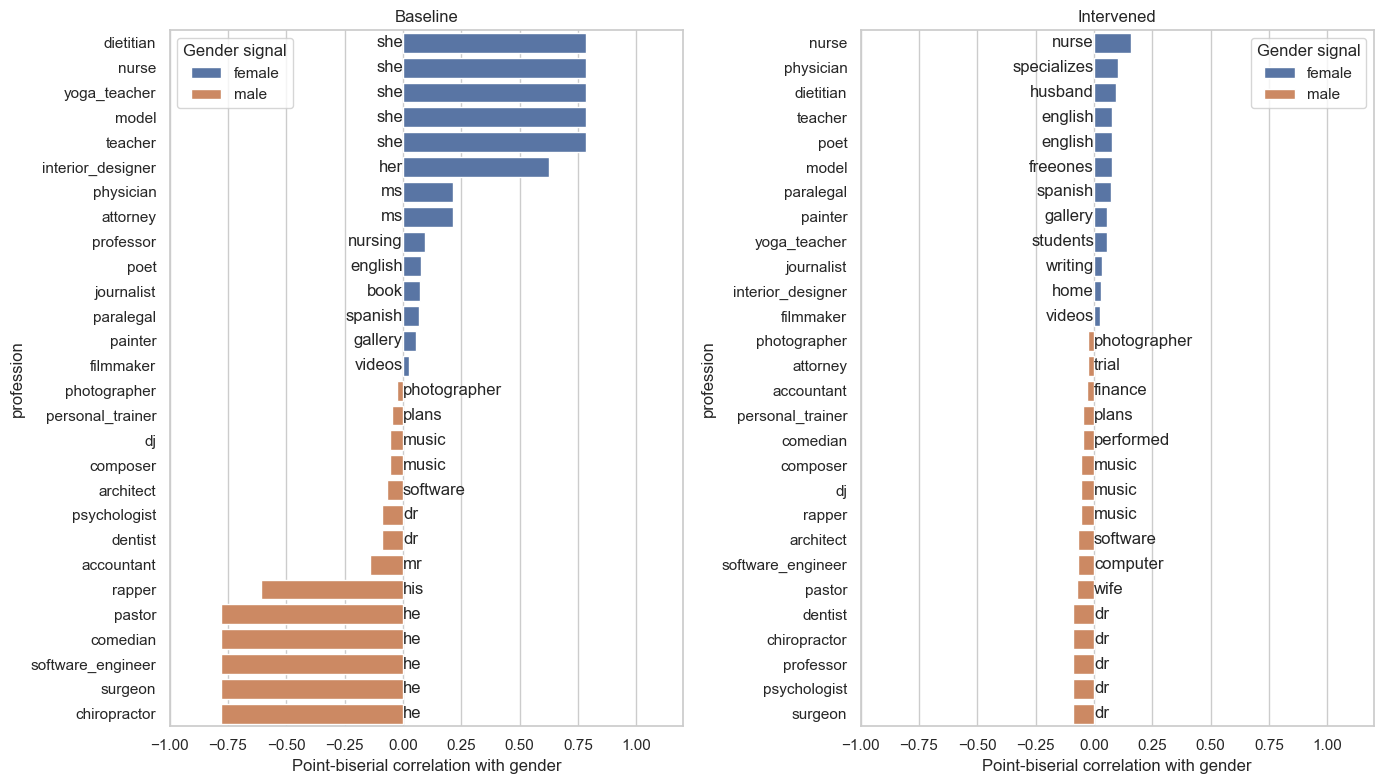

In [268]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

plot_gender_correlations(result_df, feature_rank=0, ax=ax1)
ax1.set_title("Baseline")

plot_gender_correlations(result_no_pronouns_df, feature_rank=0, ax=ax2)
ax2.set_title("Intervened")

plt.tight_layout()
plt.savefig("report/figures/gender_bias_comparison.png", bbox_inches="tight", dpi=150)


Many of the strong correlations are significantly reduced compared to the 
biased model. 

However, residual gendered signal remains: *wife* and *husband* appear as top 
features 
in the intervened model, indicating that gendered language beyond explicit 
pronouns is still present in the vocabulary. This is expected given the 
targeted scope of the intervention.

### Interpretation

Interpretability enabled a precise, targeted intervention: because the weight 
matrix directly exposed which tokens carried gender signal, the intervention 
required changing exactly nine tokens — nothing else. The result is a partial 
debiasing: gender signal is reduced by 40% with no loss in classification 
performance, demonstrating that the accuracy-fairness trade-off is not 
inevitable at this level of model complexity.

The intervention is partial because gendered language extends beyond explicit 
pronouns. Tokens such as *wife* and *husband* remain in the intervened model's 
top features, carrying residual signal the stop list did not reach. A more 
complete debiasing would require either a broader intervention or a method that 
suppresses gender information directly in the representation space — an approach 
explored in later projects in this capstone arc.

## Summary

This project trained a logistic regression classifier on the BiasBios dataset 
to predict occupation from professional biography text, achieving 76% accuracy 
and a macro F1 of 0.68 against a majority class baseline of 30% accuracy and 
0.02 macro F1. The direct interpretability of logistic regression, a 
consequence of its linear weight matrix, allowed the ethics analysis to be 
conducted without a separate probe.

The logit contributions of the top 25 weighted features per profession were 
correlated with the ground truth gender variable, revealing that gendered 
pronouns such as *she* and *he* are the dominant gender signal, concentrated 
in a small number of features rather than distributed across the weight vector. 
This inspection motivated a controlled intervention: removing nine pronoun 
tokens reduced mean |r| from 0.035 to 0.021 — a 40% reduction — while leaving 
macro F1 unchanged at 0.68. Interpretability enabled a targeted, measurable 
debiasing action at no cost to performance.

It should be noted that this suppression is superficial: as model expressivity 
grows, gender can be reconstructed from subtler co-occurring vocabulary even 
without explicit pronouns. The bias does not disappear; it becomes harder to 
detect. This motivates the broader question of the capstone arc: as model 
complexity grows and the weight matrix gives way to opaque intermediate 
representations, recovering interpretability will require dedicated tools such 
as linear probes and sparse autoencoders.